In [1]:
import pandas as pd
import polars as pl
from datetime import date
from rake_nltk import Rake
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Loading to db
# importing os module for environment variables
import os
# importing necessary functions from dotenv library
from dotenv import load_dotenv 
# loading variables from .env file
load_dotenv() 
import psycopg2
from sqlalchemy import create_engine

# Final Raw Pubmed Data (no abstract or author)

In [3]:
pm_df = pd.read_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/data/raw/final_raw_pubmed_data.csv")

In [4]:
pm_df.info()
# 10,206,788 rows

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   Unnamed: 0  int64
 1   title       str  
 2   journal     str  
 3   date        str  
 4   doi         str  
dtypes: int64(1), str(4)
memory usage: 2.0 GB


In [5]:
pm_df = pm_df.drop(['Unnamed: 0'], axis = 1)

In [6]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 4 columns):
 #   Column   Dtype
---  ------   -----
 0   title    str  
 1   journal  str  
 2   date     str  
 3   doi      str  
dtypes: str(4)
memory usage: 2.0 GB


In [ ]:
print(pm_df['date'].astype(str).str.len().value_counts())


date
10    10201811
4         4977
Name: count, dtype: int64


In [11]:
pm_df['date'] = pd.to_datetime(pm_df['date'], format='mixed', errors='coerce')

In [12]:
print(pm_df['date'].astype(str).str.len().value_counts())


date
10    10206788
Name: count, dtype: int64


In [13]:
pd.to_datetime(pm_df['date'])

0          2006-10-20
1          2006-10-28
2          2006-10-14
3          2006-10-31
4          2006-10-26
              ...    
10206783   2026-06-15
10206784   2026-06-23
10206785   2026-06-11
10206786   2026-06-03
10206787   2026-06-03
Name: date, Length: 10206788, dtype: datetime64[us]

In [14]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 4 columns):
 #   Column   Dtype         
---  ------   -----         
 0   title    str           
 1   journal  str           
 2   date     datetime64[us]
 3   doi      str           
dtypes: datetime64[us](1), str(3)
memory usage: 1.9 GB


In [23]:
pm_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10206788 entries, 0 to 10206787
Data columns (total 5 columns):
 #   Column   Dtype         
---  ------   -----         
 0   title    str           
 1   journal  str           
 2   date     datetime64[us]
 3   doi      str           
 4   year     int32         
dtypes: datetime64[us](1), int32(1), str(3)
memory usage: 1.9 GB


In [22]:
pm_df['year'] = pm_df['date'].dt.year


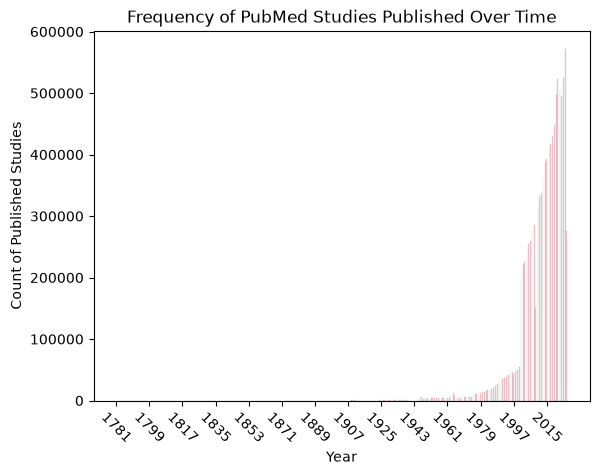

In [65]:
sns.histplot(data = pm_df, x='year', binwidth=0.4, color='pink')
plt.xticks(np.arange(1781, 2027, step = 18), rotation = -45)
plt.xlabel("Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of PubMed Studies Published Over Time")
plt.show()

# cleaned_raw_pubmed_data.csv into LAZYFRAME

In [40]:
raw_df = pl.scan_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/notebooks/Article_Data_APIs/data/cleaned_raw_pubmed_data.csv")

In [19]:
raw_df.select(pl.len()).collect().item()
# 10,206,788 rows

10206788

In [20]:
raw_df.head(2).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Anti-tumor necrosis factor-alp…","""The aim of this study was to a…","""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","""To investigate quantification …","""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null


## Date Cleaning for that one column

In [ ]:
# Find all the length of all unique dates
raw_df.select(pl.col('date').cast(pl.String).str.len_chars()).unique().collect()
# 4, 10, and 98
# 98 is odd

In [ ]:
# The 98 was the formatting issue which is taken care of in the pubmed_final_data_export.ipynb
raw_df.filter(pl.col('date').cast(pl.String).str.len_chars() == 98).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Comparing Essure® and Tubal Li…","""Hundreds of thousands of US wo…","""2021""","""['Aileen M.Gariepy', 'Daniel J…","""10.25302/10.2021.CER.160936359""",null


In [ ]:
# Define row that is all shifted over
row = pl.col('date').cast(pl.String).str.len_chars() == 98

In [ ]:
# Replace like we did in pubmed_final_data_export
f_raw_df = raw_df.with_columns([
    pl.when(row).then(pl.col('date')).otherwise(pl.col('authors')).alias('authors'),
    pl.when(row).then(pl.col('journal')).otherwise(pl.col('date')).alias('date'),
    pl.when(row).then(None).otherwise(pl.col('journal')).alias('journal')
])

In [ ]:
# Check to see if the row changed
f_raw_df.filter(pl.col('doi') == "10.25302/10.2021.CER.160936359").collect()
# YAY IT DID

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Comparing Essure® and Tubal Li…","""Hundreds of thousands of US wo…",null,"""2021""","""['Aileen M.Gariepy', 'Daniel J…","""10.25302/10.2021.CER.160936359"""


In [ ]:
# Find the row with 4
raw_df.filter(pl.col('date').cast(pl.String).str.len_chars() == 4).collect()

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Molecular Imaging and Contrast…","""The Molecular Imaging and Cont…",null,"""2004""","""[]""",null
"""Screening for Hereditary Hemoc…","""To assess evidence sufficiency…",null,"""2006""","""['Evelyn PWhitlock', 'Betsy AG…",null
"""WHO Guideline on Syphilis Scre…","""Since the publication of the W…",null,"""2017""","""[]""",null
"""Using nationwide ‘big data’ fr…","""Electronic health records (EHR…",null,"""2017""","""['HarryHemingway', 'Gene SFede…","""10.3310/pgfar05040"""
"""Can Coping-Skills Training Hel…","""Many survivors of critical ill…",null,"""2018""","""['Christopher E.Cox', 'Catheri…","""10.25302/9.2018.CER.195"""
…,…,…,…,…,…
"""Recommendations for Drug Thera…","""Evidence-informed recommendati…",null,"""2013""","""[]""",null
"""Evidence review for previous c…","""The aim of this review is to d…",null,"""2019""","""['NoneNone']""",null
"""WHO consolidated guidelines fo…","""Respiratory illness remains a …",null,"""2026""","""[]""",null


In [ ]:
# Standardize the date column to make sure it has 10
ff_raw_df = f_raw_df.with_columns(
    pl.when(pl.col('date').cast(pl.String).str.len_chars() == 4).then(pl.col('date').cast(pl.String) + "-01-01")
    .otherwise(pl.col('date').cast(pl.String))
)

In [ ]:
# Check to see if it worked
ff_raw_df.select(pl.col('date').cast(pl.String).str.len_chars()).unique().collect()
# Yay it worked!

date
u32
10


In [43]:
ff_raw_df.select(pl.col('date').max()).collect()

date
str
"""2026-07-01"""


In [55]:
ff_raw_df.select(pl.col('date').min()).collect()

date
str
"""1781-06-01"""


### Change date to datetime

In [44]:
# Change rows to datetime
dt_raw_df = ff_raw_df.with_columns(
    pl.col('date').str.strptime(pl.Date, format = "%Y-%m-%d")
    )

In [15]:
#pl.Config.restore_defaults()
dt_raw_df.head(2).collect()

NameError: name 'dt_raw_df' is not defined

### Drop authors column

In [58]:
dt_drop_raw_df = dt_raw_df.drop(['authors'])

## Now I want to filter for only years between 1948 - 2026

In [26]:
# Filter between 1948 - 2026
fil_raw_df = dt_raw_df.filter(pl.col('date').is_between(date(1948, 1, 1), date(2026, 6, 30)))

In [ ]:
# Check row count now
fil_raw_df.select(pl.len()).collect().item()
# 10,185,407
# Too big

10185407

In [ ]:
#raw_df_00_26.select(pl.len()).collect().item()
# 9,380,169
# #raw_df_00_26.collect().estimated_size("mb")
# 14 GB

9380169

In [55]:
#pl.Config(fmt_str_lengths=2000, tbl_rows=2)
fil_raw_df.head(2).collect()

title,abstract,journal,date,authors,doi
str,str,str,date,str,str
"""Anti-tumor necrosis factor-alp…","""The aim of this study was to a…","""Rheumatology international""",2006-10-20,"""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","""To investigate quantification …","""Beijing da xue xue bao. Yi xue…",2006-10-28,"""['Zhan-kunChen', 'Hou-shanLv']""",null


## Thought
### What if I instead of filtering for years, and only doing 2000 - 2026 or even less, I can try and extract keywords from the abstract of the lazy frame and then save that as a csv.

### Test

In [15]:
# Make a small test lazyframe
test = raw_df.head(5).collect()

In [16]:
test

title,abstract,journal,date,authors,doi
str,str,str,str,str,str
"""Anti-tumor necrosis factor-alp…","""The aim of this study was to a…","""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","""To investigate quantification …","""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null
"""Interleukin-7 induced immunopa…","""Interleukin (IL)-7 is a potent…","""Annals of the rheumatic diseas…","""2006-10-14""","""['S A YHartgring', 'J W JBijls…","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…","""Rapid, quantitative methods su…","""Methods in molecular biology (…","""2006-10-31""","""['Karen JRees-Milton', 'Tassos…","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""['Michael AMont', 'David SHung…","""10.3928/01477447-20061001-13"""


In [17]:
# View lenngth of each abstract
test.with_columns(
    pl.col('abstract').str.len_chars()
)

title,abstract,journal,date,authors,doi
str,u32,str,str,str,str
"""Anti-tumor necrosis factor-alp…",925,"""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …",1589,"""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null
"""Interleukin-7 induced immunopa…",1425,"""Annals of the rheumatic diseas…","""2006-10-14""","""['S A YHartgring', 'J W JBijls…","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…",1730,"""Methods in molecular biology (…","""2006-10-31""","""['Karen JRees-Milton', 'Tassos…","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""['Michael AMont', 'David SHung…","""10.3928/01477447-20061001-13"""


In [74]:
with pl.Config(fmt_str_lengths=2000, tbl_rows=2):
    print(test.tail(2))

shape: (2, 6)
┌─────────────────┬─────────────────┬─────────────┬────────────┬─────────────────┬─────────────────┐
│ title           ┆ abstract        ┆ journal     ┆ date       ┆ authors         ┆ doi             │
│ ---             ┆ ---             ┆ ---         ┆ ---        ┆ ---             ┆ ---             │
│ str             ┆ str             ┆ str         ┆ str        ┆ str             ┆ str             │
╞═════════════════╪═════════════════╪═════════════╪════════════╪═════════════════╪═════════════════╡
│ High-throughput ┆ Rapid,          ┆ Methods in  ┆ 2006-10-31 ┆ ['Karen         ┆ 10.1385/1-59745 │
│ quantitation of ┆ quantitative    ┆ molecular   ┆            ┆ JRees-Milton',  ┆ -167-3:267      │
│ metabolically   ┆ methods suited  ┆ biology     ┆            ┆ 'Tassos PAnasta ┆                 │
│ labeled anionic ┆ to a large      ┆ (Clifton,   ┆            ┆ ssiades']       ┆                 │
│ glycoconjugates ┆ number of       ┆ N.J.)       ┆            ┆             

In [22]:
def extract_keyword(text):
    if text is None:
        return []
    r = Rake()
    r.extract_keywords_from_text(str(text))
    return list(dict.fromkeys(r.get_ranked_phrases())) # adding a check to remove duplicates because there seems to be a lot

test_keyword = test.with_columns([
    pl.col('abstract').map_elements(extract_keyword, return_dtype = pl.List(pl.String))
])


In [23]:
test_keyword

title,abstract,journal,date,authors,doi
str,list[str],str,str,str,str
"""Anti-tumor necrosis factor-alp…","[""infliximab treatment significantly lowered"", ""gamma inducible protein"", … ""14""]","""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","[""could also remarkably diminish ltb4"", ""lox exciting protein flap inhibitor"", … ""00""]","""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null
"""Interleukin-7 induced immunopa…","[""7 induces tumour necrosis factor alpha"", ""mig ), macrophage inflammatory protein"", … ""able""]","""Annals of the rheumatic diseas…","""2006-10-14""","""['S A YHartgring', 'J W JBijls…","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…","[""wallac 1450 microbeta trilux"", ""n )]- glucosamine allows"", … ""3h""]","""Methods in molecular biology (…","""2006-10-31""","""['Karen JRees-Milton', 'Tassos…","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""['Michael AMont', 'David SHung…","""10.3928/01477447-20061001-13"""


In [24]:
# view length of each abstract
test_keyword.with_columns(
    pl.col('abstract').list.len()
)

title,abstract,journal,date,authors,doi
str,u32,str,str,str,str
"""Anti-tumor necrosis factor-alp…",41,"""Rheumatology international""","""2006-10-20""","""['YasunoriKageyama', 'EijiTori…","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …",79,"""Beijing da xue xue bao. Yi xue…","""2006-10-28""","""['Zhan-kunChen', 'Hou-shanLv']""",null
"""Interleukin-7 induced immunopa…",72,"""Annals of the rheumatic diseas…","""2006-10-14""","""['S A YHartgring', 'J W JBijls…","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…",85,"""Methods in molecular biology (…","""2006-10-31""","""['Karen JRees-Milton', 'Tassos…","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""['Michael AMont', 'David SHung…","""10.3928/01477447-20061001-13"""


In [26]:
# abstract is now a string in a list so we need to add fmt table cell list len...

with pl.Config(fmt_str_lengths=2000, fmt_table_cell_list_len=100, tbl_rows=2):
    print(test_keyword.head(2))

shape: (2, 6)
┌─────────────────┬────────────────┬────────────────┬────────────┬────────────────┬────────────────┐
│ title           ┆ abstract       ┆ journal        ┆ date       ┆ authors        ┆ doi            │
│ ---             ┆ ---            ┆ ---            ┆ ---        ┆ ---            ┆ ---            │
│ str             ┆ list[str]      ┆ str            ┆ str        ┆ str            ┆ str            │
╞═════════════════╪════════════════╪════════════════╪════════════╪════════════════╪════════════════╡
│ Anti-tumor      ┆ ["infliximab   ┆ Rheumatology   ┆ 2006-10-20 ┆ ['YasunoriKage ┆ 10.1007/s00296 │
│ necrosis        ┆ treatment      ┆ international  ┆            ┆ yama',         ┆ -006-0241-1    │
│ factor-alpha    ┆ significantly  ┆                ┆            ┆ 'EijiTorikai', ┆                │
│ antibody        ┆ lowered",      ┆                ┆            ┆ 'AkiraNagano'] ┆                │
│ treatment       ┆ "gamma         ┆                ┆            ┆           

### Save cleaned lazyframe as a csv and then use it to extract keywords

In [60]:
dt_drop_raw_df.sink_csv('pubmed_cleaned_drop_author.csv')

### Extracting keywords for entire dataframe

In [41]:
rcd = pl.scan_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/notebooks/Article_Data_APIs/data/pubmed_cleaned_drop_author.csv")

In [62]:
rcd.select(pl.len()).collect().item()

10206788

In [63]:
def extract_keyword(text):
    if text is None:
        return []
    r = Rake()
    r.extract_keywords_from_text(str(text))
    return list(dict.fromkeys(r.get_ranked_phrases())) 

keyword_rcd = rcd.with_columns([
    pl.col('abstract').map_elements(extract_keyword, return_dtype = pl.List(pl.String))
])

In [64]:
keyword_rcd.select(pl.len()).collect().item()

10206788

In [69]:
keyword_rcd_test = keyword_rcd.head(15).collect()

In [71]:
keyword_rcd_test

title,abstract,journal,date,doi
str,list[str],str,str,str
"""Anti-tumor necrosis factor-alp…","[""infliximab treatment significantly lowered"", ""gamma inducible protein"", … ""14""]","""Rheumatology international""","""2006-10-20""","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …","[""could also remarkably diminish ltb4"", ""lox exciting protein flap inhibitor"", … ""00""]","""Beijing da xue xue bao. Yi xue…","""2006-10-28""",null
"""Interleukin-7 induced immunopa…","[""7 induces tumour necrosis factor alpha"", ""mig ), macrophage inflammatory protein"", … ""able""]","""Annals of the rheumatic diseas…","""2006-10-14""","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…","[""wallac 1450 microbeta trilux"", ""n )]- glucosamine allows"", … ""3h""]","""Methods in molecular biology (…","""2006-10-31""","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""10.3928/01477447-20061001-13"""
…,…,…,…,…
"""Heat shock proteins induce T c…","[""antigen specific immunotherapy approach involving modulation"", ""bacterial hsps inhibited disease development"", … ""anti""]","""Annals of the rheumatic diseas…","""2006-10-14""","""10.1136/ard.2006.058495"""
"""Detection of novel intracellul…","[""synuclein oligomerization using fluorescence lifetime imaging"", ""carboxy terminus interaction within single alpha"", … ""adopt""]","""FASEB journal : official publi…","""2006-10-03""","""10.1096/fj.05-5422com"""
"""AMG 531, a thrombopoiesis-stim…","[""amg 531 per kilogram per week"", ""receive six weekly subcutaneous injections"", … ""0""]","""The New England journal of med…","""2006-10-20""","""10.1056/NEJMoa054626"""


In [70]:
keyword_rcd_test.with_columns(
    pl.col('abstract').list.len()
)

title,abstract,journal,date,doi
str,u32,str,str,str
"""Anti-tumor necrosis factor-alp…",41,"""Rheumatology international""","""2006-10-20""","""10.1007/s00296-006-0241-1"""
"""[Quantification of expression …",79,"""Beijing da xue xue bao. Yi xue…","""2006-10-28""",null
"""Interleukin-7 induced immunopa…",72,"""Annals of the rheumatic diseas…","""2006-10-14""","""10.1136/ard.2006.058479"""
"""High-throughput quantitation o…",85,"""Methods in molecular biology (…","""2006-10-31""","""10.1385/1-59745-167-3:267"""
"""Pulsed electrical stimulation …",null,"""Orthopedics""","""2006-10-26""","""10.3928/01477447-20061001-13"""
…,…,…,…,…
"""Heat shock proteins induce T c…",73,"""Annals of the rheumatic diseas…","""2006-10-14""","""10.1136/ard.2006.058495"""
"""Detection of novel intracellul…",48,"""FASEB journal : official publi…","""2006-10-03""","""10.1096/fj.05-5422com"""
"""AMG 531, a thrombopoiesis-stim…",96,"""The New England journal of med…","""2006-10-20""","""10.1056/NEJMoa054626"""


In [ ]:
# Check estimated size
keyword_rcd.collect().estimated_size("mb")
# 10.2 GB

10279.678154945374

## Try and pull gender or something like that out of the full abstract

### test

In [8]:
pull_abstract = raw_df.tail(20).collect()

In [9]:
with pl.Config(fmt_str_lengths=2000, tbl_rows=2):
    print(pull_abstract)

shape: (20, 6)
┌─────────────────┬─────────────────┬─────────────┬────────────┬─────────────────┬─────────────────┐
│ title           ┆ abstract        ┆ journal     ┆ date       ┆ authors         ┆ doi             │
│ ---             ┆ ---             ┆ ---         ┆ ---        ┆ ---             ┆ ---             │
│ str             ┆ str             ┆ str         ┆ str        ┆ str             ┆ str             │
╞═════════════════╪═════════════════╪═════════════╪════════════╪═════════════════╪═════════════════╡
│ Five Decades of ┆ null            ┆ PET clinics ┆ 2026-06-27 ┆ ['Andrew        ┆ 10.1016/j.cpet. │
│ [18F]Fluorodeox ┆                 ┆             ┆            ┆ BNewberg',      ┆ 2026.06.004     │
│ yglucose-PET in ┆                 ┆             ┆            ┆ 'EricGuedj',    ┆                 │
│ Neuropsychiatri ┆                 ┆             ┆            ┆ 'AbassAlavi']   ┆                 │
│ c Disorders:    ┆                 ┆             ┆            ┆            

In [20]:
search = r'\bfemale patient(s)?\b'
search_mask = pull_abstract.filter(pl.col('abstract').str.contains(search).fill_null(False))
search_mask

title,abstract,journal,date,authors,doi
str,str,str,str,str,str


In [22]:
raw_df1 = raw_df.collect()

In [39]:
'''
with pl.Config(fmt_str_lengths=2000, tbl_rows=2):
    print(search_mask1.tail(2))
'''

'\nwith pl.Config(fmt_str_lengths=2000, tbl_rows=2):\n    print(search_mask1.tail(2))\n'

### search

In [42]:
search2 = r'(?i)\bfemale patient(s)?\b|\bfemale participant(s)?\b|\bfemale subject(s)?\b|\bfemale volunteer(s)?\b|\bfemale individual(s)?\b|\bfemale group(s)?\b|\bfemale case(s)?\b|\bfemale control(s)?\b|\bfemale enrollee(s)?\b|\bfemale recruit(s)?\b|\bwomen\b|\bwoman\b|\bpregnant\b|\bpregnancy\b|\bmaternal\b|\bgestational\b|\bpostpartum\b|\bantenatal\b|\bprenatal\b|\bnulliparous\b|\bmultiparous\b|\buterine\b|\buterus\b|\bovarian\b|\bovary\b|\bovaries\b|\bendometrium\b|\bendometriosis\b|\bvagina\b|\bvaginal\b|\bvaginosis\b|\bvulva\b|\bmenopause\b|\bmenopausal\b|\bmenstruation\b|\bmenstrual\b|\bmenarche\b|\bpap smear\b|\bpcos\b|\bpreeclampsia\b|\beclampsia\b|\bhysterectomy\b|\boophorectomy\b|\bsalpingectomy\b|\bmyomectomy\b|\bmammogram\b|\bmammography\b|\bXX chromosome\b|\bcontraceptive(s)?\b|\boestrogen\b|\bestradiol\b|\bovulation\b|\bintrauterine\b|\bsalpingo-oophorectomy\b|\bcolposcopy\b|\bovarian insufficiency\b|\bovarian failure\b|\bamenorrhea\b|\buterine hypoplasia\b|\bplacenta\b|\bplacental\b|\bmultiparity\b|\bgrand multiparity\b|\bamniotic\b|\blactiferous\b|\badenomyosis\b|\bchoriocarcinoma\b|\bleiomyoma\b|\bendocervix\b|\bectocervix\b|\bcervix\b|\banovulation\b|\bcerclage\b|\bdysplasia\b|\bdyspareunia\b|\bmenses\b|\bspeculum\b|\btransvaginal\b|\bhysteria\b|\bwandering womb\b|\bchlorosis\b|\bclimacteric\b|\baccubation\b|\bpuerperal\b|\bprimiparous\b|\bvulvovaginal\b|\bcolporrhaphy\b|\bepisiotomy\b|\bpessary\b|\bpessaries\b|\biud\b|\bchorioamnionitis\b|\bhyperemesis gravidarum\b|\bhysterectomy\b|\binfertility\b|\boral contraceptives\b|\bcervical\b|\bclitoris\b|\bcolposcopy\b|\bconization\b|\bcystocele\b|\bgroup b streptococcus\b'
search_mask2 = pl.col('abstract').str.to_lowercase().str.contains(search2).fill_null(False)
# 1,902,612

In [43]:
# Add new column
added_column_df = (raw_df.with_columns(pl.when(search_mask2).then(pl.lit("yes")).otherwise(pl.lit("no")).alias("includes_female"))).collect()

In [45]:
dff = added_column_df.filter(pl.col('includes_female') == 'yes')

In [46]:
dff_drop = dff.drop(['abstract'], ['authors'])

In [51]:
dff_drop.filter(pl.col('date').cast(pl.String).str.len_chars() == 98)

title,journal,date,doi,includes_female
str,str,str,str,str
"""Comparing Essure® and Tubal Li…","""2021""","""['Aileen M.Gariepy', 'Daniel J…",null,"""yes"""


In [54]:
row = pl.col('date').cast(pl.String).str.len_chars() == 98
f_dff_df = dff_drop.with_columns([
   pl.when(row).then(pl.col('journal')).otherwise(pl.col('date')).alias('date'), 
   pl.when(row).then(None).otherwise(pl.col('journal')).alias('journal')
])
dff_drop.filter(pl.col('date').cast(pl.String).str.len_chars() == 4)
ff_dff_df = f_dff_df.with_columns(
    pl.when(pl.col('date').cast(pl.String).str.len_chars() == 4).then(pl.col('date').cast(pl.String) + "-01-01")
    .otherwise(pl.col('date').cast(pl.String))
)
sdk = ff_dff_df.with_columns(
    pl.col('date').str.strptime(pl.Date, format = "%Y-%m-%d")
    )

In [ ]:
'''
sns.histplot(ct_df[ct_df["contains_women"]], x = 'start_year', binwidth=1, color='pink')
plt.xticks(np.arange(1970, 2027, step = 5), rotation=45)
plt.xlabel("Trial Start Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of Clinical Trials Women\nContaining Studies Published Over Time")
plt.show()
'''

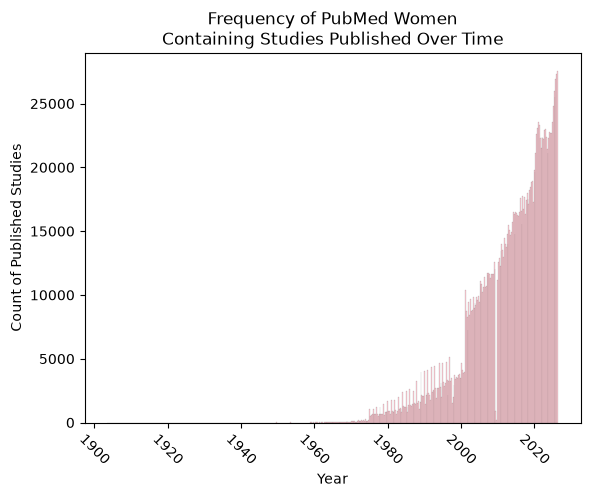

In [69]:
sns.histplot(sdk.to_pandas(), x="date", color ='pink')
plt.xticks(rotation=-45)
plt.xlabel("Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of PubMed Women\nContaining Studies Published Over Time")
plt.show()

## added_columns now had a column includes_female that either is yes or no, yes is 100% includes female, although some nos could as well

## now I need to extract keywords from the abstract and remove the authors column to then export as csv

# Reddit PubMed Data

In [40]:
rp = pd.read_csv("reddit_pubmed_data.csv")

In [41]:
rp.info()
# 2,797,950 rows

<class 'pandas.DataFrame'>
RangeIndex: 2797950 entries, 0 to 2797949
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   title     str    
 1   abstract  str    
 2   journal   str    
 3   date      str    
 4   authors   str    
 5   doi       str    
 6   keyword   str    
 7   year      float64
dtypes: float64(1), str(7)
memory usage: 4.2 GB


In [43]:
rp.head(2)

,title,abstract,journal,date,authors,doi,keyword,year
0,IV. Prolapsus of the Rectum in Children.,NaN,Annals of surgery,1900-03-01,['C GCumston'],10.1097/00000658-190001000-00028,hemorrhoids,1900.0
1,HEMIANOPSIA IN MIGRAINE.,NaN,"Science (New York, N.Y.)",1900-05-04,['J MBaldwin'],10.1126/science.11.279.713-a,migraine,1900.0


In [20]:
rp.isna().sum()

title            0
abstract    472647
journal       1881
date            13
authors          0
doi         557210
keyword          0
year            13
dtype: int64

In [22]:
rp[['title']].value_counts()

title                                                                                                                                                
[Not Available].                                                                                                                                         840
Drugs and Lactation Database (LactMed®)                                                                                                                  107
Polycystic ovary syndrome.                                                                                                                                99
Reply.                                                                                                                                                    96
Emergency contraception.                                                                                                                                  82
                                                                 

## The two different datasets

### 1. Duplicate rows: Every paper has multiple keywords (this is the original dataset)

In [45]:
rp_k = rp

In [46]:
rp_k = rp_k.drop(columns=['abstract', 'journal', 'date', 'authors'])

In [47]:
rp_k.info()

<class 'pandas.DataFrame'>
RangeIndex: 2797950 entries, 0 to 2797949
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   title    str    
 1   doi      str    
 2   keyword  str    
 3   year     float64
dtypes: float64(1), str(3)
memory usage: 446.7 MB


### To warehouse

In [48]:
# Connect to the database
conn = psycopg2.connect(
    dbname=os.getenv("DBNAME"),
    user=os.getenv("DBUSER"),
    password=os.getenv("DBPASSWORD"),
    port=os.getenv("DBPORT"),
    host=os.getenv("DBHOST")
)
conn_string=os.getenv("CONNSTRING")

# Create engine
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DBUSER')}:{os.getenv('DBPASSWORD')}"
    f"@{os.getenv('DBHOST')}:{os.getenv('DBPORT')}/{os.getenv('DBNAME')}"
)

In [50]:
rp_k.to_sql("pubmed_key", engine, if_exists="append", index=False, method="multi", chunksize=100)

2797950

### 2. Unique rows for each paper: Keywords are in a list

In [47]:
rp.duplicated(subset=['title', 'doi']).sum()

np.int64(562764)

In [48]:
rp[['title', 'doi']].value_counts()

title                                                                                                                                                                          doi                                 
An evaluation of the levonorgestrel-releasing IUD: its advantages and disadvantages when compared to the copper-releasing IUDs.                                                10.1016/0010-7824(91)90078-t            16
The characterization of patients with premature ovarian failure, endometriosis, and polycystic ovary syndrome in women attending comprehensive health centers in Urmia, Iran.  10.1186/s12905-026-04368-4              16
Hormonal intrauterine devices.                                                                                                                                                 10.3109/07853899309164158               15
Hormonal contraception.                                                                                                               

In [49]:
rp[rp['doi'] == '10.1016/0010-7824(91)90078-t'].head(20)

,title,abstract,journal,date,authors,doi,keyword,year
467831,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,irregular menstruation,1991.0
467846,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,menorrhagia,1991.0
467851,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,heavy menstrual bleeding,1991.0
467858,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,dysmenorrhea,1991.0
467879,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,amenorrhea,1991.0
467925,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,IUD,1991.0
467936,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,intrauterine device,1991.0
467945,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,copper IUD,1991.0
467946,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,levonorgestrel IUD,1991.0
467985,An evaluation of the levonorgestrel-releasing ...,"The levonorgestrel-releasing IUD (LNG-IUD-20),...",Contraception,1991-12-01,['I CChi'],10.1016/0010-7824(91)90078-t,contraceptive side effects,1991.0


In [14]:
rp_g = rp.groupby(['title', 'doi'], as_index = False, sort = False, dropna = False).agg({'abstract':'first', 'journal':'first', 'date':'first', 'authors':'first', 'year':'first', 'keyword': lambda x: list(x.dropna().unique())})

In [51]:
rp_g

,title,doi,abstract,journal,date,authors,year,keyword
0,IV. Prolapsus of the Rectum in Children.,10.1097/00000658-190001000-00028,NaN,Annals of surgery,1900-03-01,['C GCumston'],1900.0,[hemorrhoids]
1,HEMIANOPSIA IN MIGRAINE.,10.1126/science.11.279.713-a,NaN,"Science (New York, N.Y.)",1900-05-04,['J MBaldwin'],1900.0,[migraine]
2,An attempt to estimate fatigue of the cerebral...,10.1113/jphysiol.1901.sp000832,NaN,The Journal of physiology,1901-02-28,['A GLevy'],1901.0,[fatigue]
3,VII. Report of a Case of Recovery after Abdomi...,10.1097/00000658-190101000-00030,NaN,Annals of surgery,1901-03-01,['FMartin'],1901.0,[hemorrhoids]
4,A further research into fatigue of the central...,10.1113/jphysiol.1902.sp000895,NaN,The Journal of physiology,1902-03-27,['A GLevy'],1902.0,[fatigue]
...,...,...,...,...,...,...,...,...
2235181,Serotonin Degradation and Lipid Metabolism Reg...,10.1111/all.70399,Cytotoxic type 2 T cells (Tc2) are increasingl...,Allergy,2026-07-01,"['Sabrinade Souza Ferreira', 'LisaHolla', 'Sop...",2026.0,[allergic]
2235182,Investigating the Potential Pharmacological Me...,10.2174/0113862073449045260321213418,Allergic rhinitis (AR) is a common immune diso...,Combinatorial chemistry & high throughput scre...,2026-07-01,"['ZehuaLin', 'AikebaierTuohuti', 'XiupingYang'...",2026.0,[allergic]
2235183,Bridging environmental pollution and immune dy...,10.1080/21505594.2026.2690759,Parallel increases in microplastic (MP) pollut...,Virulence,2026-07-01,"['XuZhang', 'KeLiu', 'ZhiqiangZhang', 'XinyuHu...",2026.0,[allergic]
2235184,Using new approach methodologies (NAMs) to inv...,10.1038/s41598-026-60082-z,Zinc oxide nanoparticles (ZnONPs) are widely u...,Scientific reports,2026-07-01,"['Yu-YingChen', 'Bour-JrWang', 'Yung-HsuanChen...",2026.0,[allergic]


In [15]:
rp_g.duplicated(subset=['title']).sum()

np.int64(19714)

In [16]:
rp_g[['title']].value_counts()

title                                                                                                                                                
[Not Available].                                                                                                                                         684
Reply.                                                                                                                                                    92
The Authors Reply.                                                                                                                                        75
Editorial comment.                                                                                                                                        70
Chronic fatigue syndrome.                                                                                                                                 53
                                                                 

In [19]:
rp_g[rp_g['title'] == 'Reply.'].head(20)

,title,doi,abstract,journal,date,authors,year,keyword
1140172,Reply.,10.1111/j.1464-410X.2012.11011_2.x,NaN,BJU international,2012-03-30,"['YairLotan', 'MehradAdibi', 'Margaret SPearle']",2012.0,[urinary tract infection]
1356641,Reply.,10.1016/j.ajog.2015.09.070,NaN,American journal of obstetrics and gynecology,2015-09-27,"['Laurence BMcCullough', 'AmirhosseinMoaddab',...",2015.0,[tubal ligation]
1370096,Reply.,10.1016/j.ajog.2015.10.917,NaN,American journal of obstetrics and gynecology,2015-11-03,"['ElizabethChiao', 'Elizabeth AStier']",2015.0,[sexually transmitted infection]
1372765,Reply.,10.1016/j.ajog.2015.11.041,NaN,American journal of obstetrics and gynecology,2015-12-26,"['IvoBrosens', 'GiuseppeBenagiano']",2015.0,"[menstrual cycle, ovarian cyst, polycystic ova..."
1378347,Reply.,10.1016/j.ajog.2015.12.035,NaN,American journal of obstetrics and gynecology,2016-01-02,"['Elaine LDuryea', 'Donald DMcIntire', 'Kennet...",2016.0,[menstrual cycle]
1396565,Reply.,10.1097/j.pain.0000000000000500,NaN,Pain,2016-04-16,"['Kenneth GAndersen', 'Helle MDuriaud', 'Helle...",2016.0,[breast pain]
1401112,Reply.,10.1016/j.jaci.2016.01.042,NaN,The Journal of allergy and clinical immunology,2016-04-17,"['KlausBønnelykke', 'Nadja HawwaVissing', 'Ast...",2016.0,[allergic]
1438980,Reply.,10.1016/j.jaip.2016.09.010,NaN,The journal of allergy and clinical immunology...,2016-11-12,"['Paul JTurner', 'AudreyDunnGalvin', ""Jonathan...",2016.0,[allergic]
1447893,Reply.,10.1002/acr.23019,NaN,Arthritis care & research,2017-01-28,"['PatriciaKatz', 'MaryMargaretten', 'GabrielaS...",2017.0,[fatigue]
1471157,Reply.,10.1097/j.pain.0000000000000868,NaN,Pain,2017-05-18,"['SamairaYounis', 'StineMaarbjerg', 'LarsBendt...",2017.0,[headache]


### To CSV

In [52]:
rp_g.to_csv('key_pubmed.csv')